In [1]:
# external lib imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [2]:
# internal lib import
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

from core import NeuralNetwork


In [3]:
# 1. Load the dataset
df = pd.read_csv("../data/datasetml_2026.csv")

In [4]:
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [5]:
# 2. Separate Features (X) and Target (y)
X = df.drop(columns=['placement_status'])
y = df['placement_status'].values
y = np.where(y == "Placed", 1, 0) 

# 3. Preprocess Categorical and Numerical Columns
categorical_cols = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
numerical_cols = ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

# 4. Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Reshape y for the Neural Network to (batch_size, 1) or one-hot encode it depending on your loss function
# If using Binary Cross Entropy:
y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (8000, 23)
y_train shape: (8000, 1)



--- Training Narrow (16 neurons) ---
Epoch 50/50 [==============================>] - train_loss: 0.640084 - val_loss: 0.639899

--- Training Medium (64 neurons) ---
Epoch 50/50 [==============================>] - train_loss: 0.558020 - val_loss: 0.559775

--- Training Wide (128 neurons) ---
Epoch 50/50 [==============================>] - train_loss: 0.564709 - val_loss: 0.564708


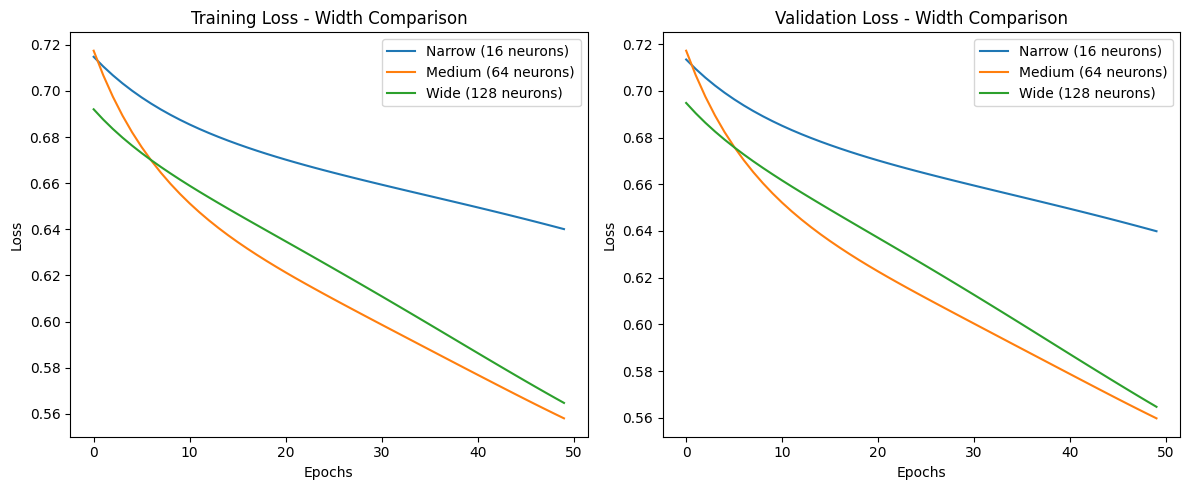

In [6]:
# Assuming input_dim is derived from X_train.shape[1]
input_dim = X_train.shape[1]
output_dim = 1 # 1 for Binary Classification

# 1. Fixed Depth (3 Hidden Layers), Varying Widths
width_configs = [
    {"name": "Narrow (16 neurons)", "layers": [input_dim, 16, 16, 16, output_dim]},
    {"name": "Medium (64 neurons)", "layers": [input_dim, 64, 64, 64, output_dim]},
    {"name": "Wide (128 neurons)",  "layers": [input_dim, 128, 128, 128, output_dim]}
]

# We will store the history of each model to plot later
histories_width = {}

for config in width_configs:
    print(f"\n--- Training {config['name']} ---")
    
    # Create activations list (length is len(layers) - 1)
    # Using ReLU for hidden, Sigmoid for output
    acts = ["relu", "relu", "relu", "sigmoid"] 
    
    # Initialize your model
    model = NeuralNetwork(
        layer_sizes=config["layers"],
        activations=acts,
        loss="bce" # Assuming Binary Cross Entropy
    )
    
    # Train
    history = model.fit(
        X_train=X_train, 
        y_train=y_train, 
        val_data=(X_val, y_val),
        epochs=50, 
        batch_size=32, 
        learning_rate=0.01,
        verbose=1
    )
    
    histories_width[config['name']] = history

# 2. Plotting the Comparison [cite: 96]
plt.figure(figsize=(12, 5))

# Plot Training Loss
plt.subplot(1, 2, 1)
for name, hist in histories_width.items():
    plt.plot(hist['train_loss'], label=name)
plt.title('Training Loss - Width Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Validation Loss
plt.subplot(1, 2, 2)
for name, hist in histories_width.items():
    plt.plot(hist['val_loss'], label=name)
plt.title('Validation Loss - Width Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()